In [15]:
import pandas as pd

# Load the Excel file
file_path = "ML_Data_Vol_Fraction.xlsx"
df = pd.ExcelFile(file_path)

# Display sheet names to see what's inside
df.sheet_names

['Sheet1']

In [16]:
data = pd.read_excel(file_path, sheet_name="Sheet1")

# Display first few rows
data.head()

,output,Input parameters,Unnamed: 2,Unnamed: 3
0,Fiber volume fraction (unit less),Bandwidth(mm),winding speed(mm/min),tension(Kg)
1,0.615215,21.3,18600,6.8
2,0.615119,20,18600,6.8
3,0.615092,20,18000,6.8
4,0.614441,20,10000,6.8


In [17]:
# Clean dataset: first row is headers
data.columns = ["output", "Bandwidth_mm", "Winding_speed_mm_min", "Tension_Kg"]
data = data.drop(0).reset_index(drop=True)

# Convert numeric columns
data = data.astype(float)

# Show cleaned data
data.head()

,output,Bandwidth_mm,Winding_speed_mm_min,Tension_Kg
0,0.615215,21.3,18600.0,6.8
1,0.615119,20.0,18600.0,6.8
2,0.615092,20.0,18000.0,6.8
3,0.614441,20.0,10000.0,6.8
4,0.585743,20.0,10000.0,4.2


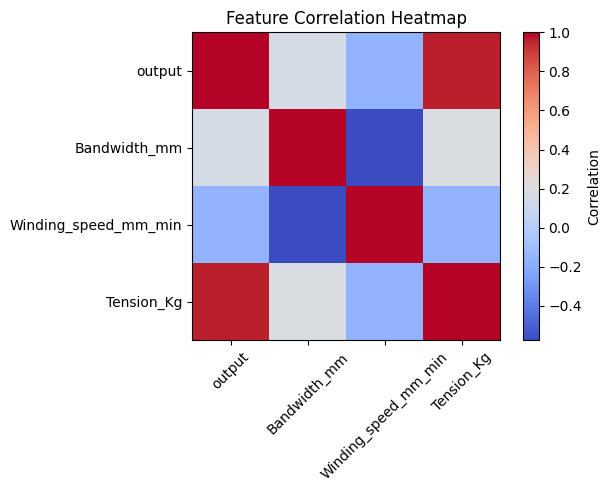

output                  1.000000
Tension_Kg              0.958983
Bandwidth_mm            0.167028
Winding_speed_mm_min   -0.153500
Name: output, dtype: float64

In [ ]:
# import matplotlib.pyplot as plt

# # Correlation matrix
# corr = data.corr()

# # Plot correlation heatmap
# plt.figure(figsize=(6,4))
# plt.imshow(corr, cmap="coolwarm", interpolation="none")
# plt.colorbar(label="Correlation")
# plt.xticks(range(len(corr)), corr.columns, rotation=45)
# plt.yticks(range(len(corr)), corr.columns)
# plt.title("Feature Correlation Heatmap")
# plt.show()

# corr["output"].sort_values(ascending=False)

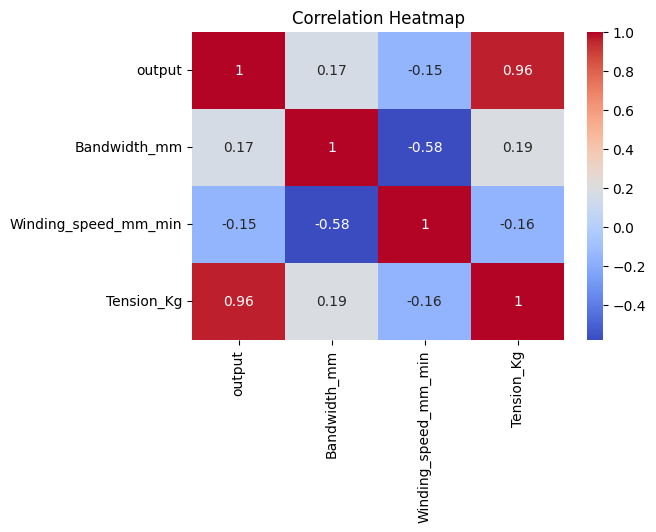

output                  1.000000
Tension_Kg              0.958983
Bandwidth_mm            0.167028
Winding_speed_mm_min   -0.153500
Name: output, dtype: float64


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print(corr["output"].sort_values(ascending=False))

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = data[["Bandwidth_mm", "Winding_speed_mm_min", "Tension_Kg"]]
y = data["output"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


R² Score: 0.8876468555460141
MSE: 8.598624514338603e-05
Coefficients: [-1.78708123e-04 -5.50726559e-08  9.47751230e-03]
Intercept: 0.5570335151205532


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest R²: 0.996882680563326


In [22]:
# Example new input
new_data = [[21.0, 15000, 6.5]]   # [Bandwidth_mm, Winding_speed_mm_min, Tension_Kg]

# Linear Regression prediction
pred_linear = model.predict(new_data)
print("Predicted Output (Linear Regression):", pred_linear[0])

# Random Forest prediction
pred_rf = rf.predict(new_data)
print("Predicted Output (Random Forest):", pred_rf[0])


Predicted Output (Linear Regression): 0.6140583846612759
Predicted Output (Random Forest): 0.6146743462146034


c:\Users\pradn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\pradn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
